In [44]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import pandas as pd

from enum import Enum

In [60]:
class DataSet(Enum):
    ONE = 1
    TWO = 2
    THREE = 3
    FOUR = 4
    FIVE = 5
    SIX = 6
    SEVEN = 7
    EIGHT = 8

data_set = DataSet.EIGHT;

class AquisitionFunction(Enum):
    UCB = 1


In [61]:

#Load initial data
match data_set:
    case DataSet.ONE:
        X = np.load("initial_data/function_1/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_1/initial_outputs.npy"))

        X = np.append(X, [[0.811933, 0.784473],\
                          [0.760428, 0.740481],\
                          [0.883211, 0.8579]], 0)
        
        y = np.append(y, [5.357376e-41,\
                          -3.988358448527149e-22,\
                          3.346982715934273e-82])
        
        print(X.shape)
        print(y.shape)
    case DataSet.TWO:
        X = np.load("initial_data/function_2/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_2/initial_outputs.npy"))

        X = np.append(X, [[0.818082, 0.926635],\
                          [0.629435, 0.979317],\
                          [0.658187, 0.220649]],0)
        
        y = np.append(y, [-0.02537857,\
                          0.16695424310575757,\
                          0.3342521887135788])
        
        print(X.shape)
        print(y.shape)
    case DataSet.THREE:
        X = np.load("initial_data/function_3/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_3/initial_outputs.npy"))

        X = np.append(X, [[0.486552, 0.999089, 0.997841],\
                          [0.488571, 0.658352, 0.181652],\
                          [0.192268, 0.359652, 0.480198]], 0)
        
        y = np.append(y, [-0.48078736,\
                          -0.11867972718508736,\
                          -0.015124747528271847])
        print(X)
        print(X.shape)
        print(y.shape)
    case DataSet.FOUR:
        X = np.load("initial_data/function_4/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_4/initial_outputs.npy"))

        X = np.append(X, [[0.004832, 0.382262, 0.921803, 0.990838],\
                          [0.489871, 0.449092, 0.426088, 0.200254],\
                          [0.443021, 0.43593, 0.46009, 0.165955]], 0)
        
        y = np.append(y, [-32.284832,\
                          -4.01093378167592,\
                          -4.038551362294328])
        
        print(X.shape)
        print(y.shape)
    case DataSet.FIVE:
        X = np.load("initial_data/function_5/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_5/initial_outputs.npy"))


        X = np.append(X, [[0.212855, 0.844288, 0.880739, 0.871421],\
                          [0.250910, 0.847168, 0.810841, 0.888456],\
                          [0.234228, 0.842623, 0.869035, 0.866812]], 0)
        
        y = np.append(y, [1052.113900,\
                          867.4163870739638,\
                          975.003291464923])
        
        print(X.shape)
        print(y.shape)
    case DataSet.SIX:
        X = np.load("initial_data/function_6/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_6/initial_outputs.npy"))


        X = np.append(X, [[0.023802, 0.008308, 0.294059, 0.011586, 0.015609],\
                          [0.660835, 0.200569, 0.706006, 0.709946, 0.078452],\
                          [0.641711, 0.172321, 0.744614, 0.703486, 0.012136]], 0)
        
        y = np.append(y, [-2.014607,\
                          -0.5747952680603831,\
                          -0.5988774103947822])
        
        print(X.shape)
        print(y.shape)
    case DataSet.SEVEN:
        X = np.load("initial_data/function_7/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_7/initial_outputs.npy"))

        X = np.append(X, [[0.104168, 0.456114, 0.256427, 0.215101, 0.372639, 0.722473],\
                          [0.159087, 0.468380, 0.250022, 0.224439, 0.388239, 0.733159],\
                          [0.148587, 0.499419, 0.292025, 0.213570, 0.358445, 0.692945]], 0)
        
        y = np.append(y, [1.796145391,\
                          1.731309761735286,\
                          1.8020727553514053])
        
        print(X.shape)
        print(y.shape)
    case DataSet.EIGHT:
        X = np.load("initial_data/function_8/initial_inputs.npy")
        y = np.transpose(np.load("initial_data/function_8/initial_outputs.npy"))

        X = np.append(X, [[0.345531, 0.274921, 0.707992, 0.654609, 0.742221, 0.787590, 0.240555, 0.887229],\
                          [0.038099, 0.066224, 0.055483, 0.121707, 0.389464, 0.807509, 0.402120, 0.958319],\
                          [0.032520, 0.049536, 0.048605, 0.092144, 0.462876, 0.837723, 0.453185, 0.952651]], 0)
        
        y = np.append(y, [8.5110526203,\
                          9.6944833424009,\
                          9.6460524474459])
        
        print(X.shape)
        print(y.shape)
    case _:
        print('No data set found')

(43, 8)
(43,)


In [62]:
# Week 1 General Code
def MakePrediction(X, y, noise_assumption,rbf_lengthscale, beta, n_samples, AF):
    # Define Model
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    #Sclae y data, x is already constrained
    scaler = sk.preprocessing.StandardScaler();

    scaler.fit(y.reshape(-1,1));
    y = scaler.transform(y.reshape(-1,1));
    
    # Fit Model
    model.fit(X, y)

    n_features = X.shape[1]

    # Create Sample points for aquisition funciton
    x_s = np.random.rand(n_samples, n_features);
    
    post_mean, post_std = model.predict(x_s, return_std=True)
    post_mean, post_std = post_mean.squeeze(), post_std.squeeze()

    if AF == AquisitionFunction.UCB:
        aquisition_function = post_mean + beta * post_std

    print("Aquisition function Max:", aquisition_function.max())
    print("Aquisition function Min:", aquisition_function.min())
    
    index = aquisition_function.argmax();

    return x_s[index,:]


In [63]:
def display_basic_stats(X, y, x_next):

    # Calc general stat of dataset
    
    mean_y = y.mean();
    std_y = y.std();

    max_y = y.max();
    min_y = y.min();

    max_pVal = (max_y - mean_y)/std_y;
    min_pVal = (mean_y-min_y)/std_y;

    print("Mean and Std of Y: ", mean_y, ", ", std_y)
    print("Max and min of Y: ", max_y, ", ", min_y)
    print("Max and Min P-Val: ", max_pVal, ", ", min_pVal)


    # Calc stas of each point
    
    order = np.flip(np.argsort(y,0)).flatten();
    
    max_y_ind = order[0];
    min_y_ind = order[-1];

    nf = X.shape[0];

    stats_raw = [];
    
    for i in range(nf):
        Index = order[i];
        Y = y[Index]
        Y_Rank = i+1;
        Max_ED = np.linalg.norm(X[Index,:]-X[max_y_ind,:])
        Max_YD = y[max_y_ind]-y[Index]
        Min_ED = np.linalg.norm(X[Index,:]-X[min_y_ind,:])
        Min_YD = y[min_y_ind]-y[Index]
        pVal = (y[Index]-mean_y)/std_y
        stats_raw.append([Index, Y, Y_Rank, Max_ED, Max_YD, Min_ED, Min_YD, pVal]);
    
    headings = ['Index', 'Y', 'Y-Rank', 'Max-Euclid-Dist', 'Max-Y-Delta', 'Min-Euclid-Dist', 'Min-Y-Delta', 'Z-Score']
    stats = pd.DataFrame(stats_raw, columns = headings)
    print(stats)

    # Calc Stats of new point
    
    dist = np.linalg.norm(X - x_next, axis=1);
    order_n = np.argsort(dist,0)
    
    stats_new = []
    
    for i in range(nf):
        Index = order_n[i];
        Y = y[Index];
        Y_rank = np.where(order==Index)[0]
        Dist = dist[Index]
        stats_new.append([Index, Y, Y_rank, Dist])

    headings = ['Index', 'Y', 'Y-Rank', 'Dist']
    stats = pd.DataFrame(stats_new, columns = headings)
    print(stats)


Aquisition function Max: 2.496289455462728
Aquisition function Min: 0.7356211853750135
Mean and Std of Y:  7.917734110156045 ,  0.9974492457492425
Max and min of Y:  9.6944833424009 ,  5.5921933895401965
Max and Min P-Val:  1.7812928726115138 ,  2.331487772963323
    Index         Y  Y-Rank  Max-Euclid-Dist  Max-Y-Delta  Min-Euclid-Dist  \
0      41  9.694483       1         0.000000     0.000000         1.727139   
1      42  9.646052       2         0.100861     0.048431         1.741202   
2      14  9.598482       3         0.142152     0.096001         1.711015   
3      26  9.344274       4         1.119353     0.350209         1.157573   
4      39  9.183005       5         0.993040     0.511478         1.358083   
5      22  9.141639       6         0.585130     0.552844         1.478783   
6      19  9.013075       7         1.264125     0.681408         1.553195   
7      12  8.976554       8         1.249986     0.717929         1.206727   
8      25  8.830745       9       

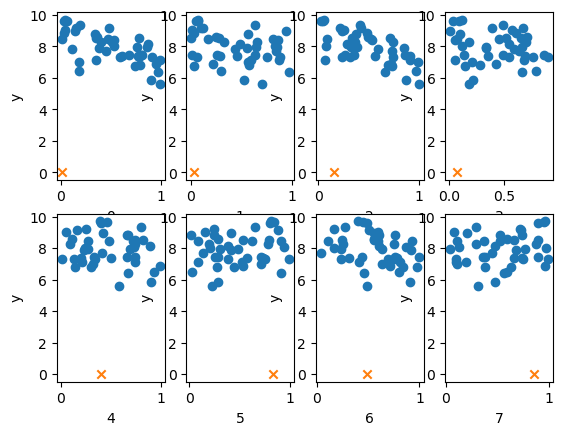

In [64]:
#Cell for processing dataset 1

noise_assumption = 1e-10;
rbf_lengthscale = 0.1;
beta = 2;
n_samples = 1000000;

AF = AquisitionFunction.UCB

# Pre Processing if required

if data_set == DataSet.ONE:
    inliers = y > 0;
    X2 = X;
    y2 = y;
    y2[inliers] = y[inliers];
    y2[~inliers] = y[inliers].min();
    y2 = np.log(y2);
    beta = 0;
    noise_assumption = 1e-5;
    rbf_lengthscale = 0.1;
if data_set == DataSet.EIGHT:
    X2 = X;
    y2 = y;
    noise_assumption = y2.std()/4;
else:
    X2 = X;
    y2 = y;
    noise_assumption = y2.std();

x_next = MakePrediction(X2,y2,noise_assumption,rbf_lengthscale, beta, n_samples, AF)
x_next = MakePredictionCNN(X2,y2)

display_basic_stats(X2, y2, x_next)

nF = X.shape[1];

fig, subs = plt.subplots(2,4);


# plot 1 dimensional distribution
for i in range(nF):
    row = int(np.floor(i/4));
    col = int(np.mod(i,4));
    subs[row][col].scatter(X2[:, i], y2, marker='o');
    subs[row][col].set(ylabel = 'y');
    subs[row][col].set(xlabel = i);
    subs[row][col].scatter(x_next[i], 0, marker='x');


print(x_next);
# print prediction
for i in range(nF):
    nD = "{:.6f}".format(x_next[i])
    print("Element: ", i, ", Value=", nD)

    